In [15]:
import kagglehub
from sklearn import preprocessing

# Download latest version
path = kagglehub.dataset_download("rabieelkharoua/alzheimers-disease-dataset")

print("Path to dataset files:", path)

# https://www.kaggle.com/code/adhamtarek147/alzheimer-s-disease-prediction
# Eksempel av løsning på datasettet
"""
@misc{rabie_el_kharoua_2024,
title={Alzheimer's Disease Dataset},
url={https://www.kaggle.com/dsv/8668279},
DOI={10.34740/KAGGLE/DSV/8668279},
publisher={Kaggle},
author={Rabie El Kharoua},
year={2024}
}
"""

Path to dataset files: C:\Users\edvar\.cache\kagglehub\datasets\rabieelkharoua\alzheimers-disease-dataset\versions\1


"\n@misc{rabie_el_kharoua_2024,\ntitle={Alzheimer's Disease Dataset},\nurl={https://www.kaggle.com/dsv/8668279},\nDOI={10.34740/KAGGLE/DSV/8668279},\npublisher={Kaggle},\nauthor={Rabie El Kharoua},\nyear={2024}\n}\n"

In [16]:
import pandas as pd
data = pd.read_csv(path + "/alzheimers_disease_data.csv")
data.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

In [18]:
data.describe()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [19]:
#som beskrevet i datasett sin beskrivelse  er doctorInCharge bare XXXconfid og dermed ikke relevant
data_cleaned = data.drop(columns=["DoctorInCharge"], axis=1)
#vi trenger heller ikkje PatientID
data_cleaned = data_cleaned.drop(columns=["PatientID"], axis=1)
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        2149 non-null   int64  
 1   Gender                     2149 non-null   int64  
 2   Ethnicity                  2149 non-null   int64  
 3   EducationLevel             2149 non-null   int64  
 4   BMI                        2149 non-null   float64
 5   Smoking                    2149 non-null   int64  
 6   AlcoholConsumption         2149 non-null   float64
 7   PhysicalActivity           2149 non-null   float64
 8   DietQuality                2149 non-null   float64
 9   SleepQuality               2149 non-null   float64
 10  FamilyHistoryAlzheimers    2149 non-null   int64  
 11  CardiovascularDisease      2149 non-null   int64  
 12  Diabetes                   2149 non-null   int64  
 13  Depression                 2149 non-null   int64

In [20]:
for column in data_cleaned.columns:
    unique_values = data_cleaned[column].unique()
    print(f"Column '{column}' has {unique_values}.")

# vi ser her at et veldig stor foskjell mellom skaleringen til nokon av verdiene med, tall fra 0-3 og nokon fra 0-100
# vi må normalisere de

Column 'Age' has [73 89 74 86 68 75 72 87 78 84 64 69 63 65 82 77 71 83 79 67 66 70 85 60
 88 62 81 61 80 90 76].
Column 'Gender' has [0 1].
Column 'Ethnicity' has [0 3 1 2].
Column 'EducationLevel' has [2 0 1 3].
Column 'BMI' has [22.92774923 26.82768119 17.79588244 ... 15.47647896 15.29991122
 33.28973831].
Column 'Smoking' has [0 1].
Column 'AlcoholConsumption' has [13.29721773  4.54252382 19.55508453 ...  4.59467018  8.67450518
  7.89070315].
Column 'PhysicalActivity' has [6.32711247 7.61988454 7.84498779 ... 9.88600229 6.35428175 6.57099338].
Column 'DietQuality' has [1.34721431 0.51876714 1.82633466 ... 8.12002455 1.26342749 7.94140388].
Column 'SleepQuality' has [9.02567867 7.15129274 9.67357416 ... 5.76946355 8.32287396 9.87871052].
Column 'FamilyHistoryAlzheimers' has [0 1].
Column 'CardiovascularDisease' has [0 1].
Column 'Diabetes' has [1 0].
Column 'Depression' has [1 0].
Column 'HeadInjury' has [0 1].
Column 'Hypertension' has [0 1].
Column 'SystolicBP' has [142 115  99 11

In [21]:
from sklearn.preprocessing import StandardScaler

columns_to_normalize = ['Age','BMI', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'SystolicBP','DiastolicBP','CholesterolTotal','CholesterolLDL','CholesterolHDL','CholesterolTriglycerides','MMSE','FunctionalAssessment','ADL']

# skalere dataen
standardScaler = StandardScaler()
data_cleaned[columns_to_normalize] = standardScaler.fit_transform(data_cleaned[columns_to_normalize])

data_cleaned.head()

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,-0.212368,0,0,2,-0.655225,0,0.565923,0.492525,-1.253593,1.119918,...,0.497506,0,0,-1.104434,0,0,0,1,0,0
1,1.567757,0,0,0,-0.114751,0,-0.954895,0.945093,-1.538442,0.056836,...,0.704907,0,0,-0.810601,0,0,0,0,1,0
2,-0.212368,0,3,1,-1.366428,0,1.653006,1.023896,-1.088855,1.487380,...,0.281813,0,0,0.724491,0,1,0,1,0,0
3,-0.101111,1,0,1,0.851625,1,0.376930,1.227995,0.839804,0.760833,...,1.343346,0,1,0.508044,0,0,0,0,0,0
4,1.567757,0,0,0,-0.961607,0,1.461793,0.486696,-1.443293,-0.824566,...,0.333665,0,0,-1.684679,0,0,1,1,0,0


In [22]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Lagd av Gemeni
# Encode the target variable since models require numerical input
le = LabelEncoder()
data_cleaned['Diagnosis'] = le.fit_transform(data_cleaned['Diagnosis'])

X = data_cleaned.drop(columns=["Diagnosis"], axis=1)
y = data_cleaned["Diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)


In [23]:
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV

# vi tester flere modeler samtidig for å finne den beste
# vi tester da gjerne modeler som har en predict_proba metode siden alzheimers som kan være skadelig å gi konkrette spådommer om
# så vil bare gi en sannsynlighet for å ha sjukdommen og en anbefaling om å ta vidare tester

# Med å sjå på eksempel løsning på datasetet(https://www.kaggle.com/code/adhamtarek147/alzheimer-s-disease-prediction) så ser vi at DecisionTreeClassifier, RandomForestClassifier, XGBClassifier og CatBoostClassifier gir gode resultater
# Dermed så tester vi disse modellene her for å se hvilken av de er den beste på vårt modifisert datasett
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric='mlogloss'),
    "CatBoost": CatBoostClassifier(verbose=0)
}

# Gitt av https://www.kaggle.com/code/adhamtarek147/alzheimer-s-disease-prediction
param_grids = {
    'Decision Tree': {'max_depth': [3, 5, 7, 12, None]},
    'Random Forest': {'n_estimators': [50, 100, 200], 'max_depth': [3, 5, 7, 12, None]},
    'XGBoost': {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 1], 'max_depth': [3, 5, 7]},
    'CatBoost': {'iterations': [50, 100, 200], 'learning_rate': [0.01, 0.1, 1]}
}

# Skrevet av Gemeni
for name, model in models.items():
    # Use 'f1_weighted' for multiclass classification scoring
    grid_search = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_weighted')
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    # Inverse transform predictions to get original labels for the report
    y_test_labels = le.inverse_transform(y_test)
    y_pred_labels = le.inverse_transform(y_pred)

    report = classification_report(y_test_labels, y_pred_labels)
    print(f'{name} Classification Report:\n{report}\nBest Parameters: {grid_search.best_params_}\n')

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       277
           1       0.93      0.87      0.90       153

    accuracy                           0.93       430
   macro avg       0.93      0.92      0.92       430
weighted avg       0.93      0.93      0.93       430

Best Parameters: {'max_depth': 5}

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       277
           1       0.96      0.84      0.90       153

    accuracy                           0.93       430
   macro avg       0.94      0.91      0.92       430
weighted avg       0.93      0.93      0.93       430

Best Parameters: {'max_depth': None, 'n_estimators': 200}

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       277
           1       0.95      0.92     

In [24]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Vi ser her at det var en stor forskjell i restultatene som vi fikk fra eksempel løsningen på datasettet og det vi fikk her
# Dermed så kan det være lurt å prøve de andre modellene også som er nevnt i eksempel løsningen på datasettet
# siden det kan hende at de er bedre egnet for dette modifiserte datasettet

models = {
    'Support Vector Machine': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Logistic Regression': LogisticRegression(),
}

# Gitt av https://www.kaggle.com/code/adhamtarek147/alzheimer-s-disease-prediction
param_grids = {
    'K-Nearest Neighbors': {'n_neighbors': [3, 5, 7]},
    'Logistic Regression': {'C': [0.1, 1, 10]},
    'Support Vector Machine': {'C': [0.1, 1, 10], 'gamma': [0.1, 1, 'scale', 'auto']},
}

# Skrevet av Gemeni
for name, model in models.items():
    # Use 'f1_weighted' for multiclass classification scoring
    grid_search = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_weighted')
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    # Inverse transform predictions to get original labels for the report
    y_test_labels = le.inverse_transform(y_test)
    y_pred_labels = le.inverse_transform(y_pred)

    report = classification_report(y_test_labels, y_pred_labels)
    print(f'{name} Classification Report:\n{report}\nBest Parameters: {grid_search.best_params_}\n')

Support Vector Machine Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.92      0.88       277
           1       0.82      0.69      0.75       153

    accuracy                           0.83       430
   macro avg       0.83      0.80      0.81       430
weighted avg       0.83      0.83      0.83       430

Best Parameters: {'C': 1, 'gamma': 'scale'}

K-Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.88      0.81       277
           1       0.68      0.48      0.56       153

    accuracy                           0.73       430
   macro avg       0.72      0.68      0.69       430
weighted avg       0.73      0.73      0.72       430

Best Parameters: {'n_neighbors': 7}

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       277
           1       0.79

In [25]:
from sklearn.utils import compute_class_weight
import numpy as np
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from scipy.stats import loguniform, randint

# Her såg vi at faktisk så var Logistic Regression den beste modellen for dette modifiserte datasettet
# med en vektet f1-score på 0.72.
# Men CatBoost var også veldig bra med en vektet f1-score på 0.73.(var lavere tidligere)
# Dermed så bruker vi desse modellen videre. Men vi vil gå dyperer inn i hyperparameter tuning for å se om vi kan få enda bedre resultater

# Skrevet av Gemeni
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression (unchanged)
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=20000, random_state=42))
])
dist_lr = {
    'clf__C': loguniform(1e-4, 1e2),
    'clf__penalty': ['l2'],
    'clf__class_weight': [None, 'balanced']
}
rs_lr = RandomizedSearchCV(pipe_lr, dist_lr, n_iter=40, scoring='f1_weighted',
                           cv=skf, n_jobs=-1, verbose=1, random_state=42, refit=True)
rs_lr.fit(X_train, y_train)
best_lr = rs_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test)
print('Logistic Regression best params:', rs_lr.best_params_)
print(classification_report(le.inverse_transform(y_test), le.inverse_transform(y_pred_lr)))


# --- Corrected CatBoost Section ---

# Compute class weights as a list
classes = np.unique(y_train)
cw = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_list = cw.tolist()

# Pass class_weights to the CatBoostClassifier constructor
base_cb = CatBoostClassifier(
    verbose=0,
    random_state=42,
    allow_writing_files=False,
    class_weights=class_weights_list
)

dist_cb = {
    'iterations': randint(100, 500),
    'learning_rate': loguniform(1e-3, 0.5),
    'depth': randint(3, 10),
    'l2_leaf_reg': loguniform(1e-3, 10)
}

rs_cb = RandomizedSearchCV(base_cb, dist_cb, n_iter=40, scoring='f1_weighted',
                           cv=skf, n_jobs=-1, verbose=1, random_state=42, refit=True)

# Call fit without the class_weights argument
rs_cb.fit(X_train, y_train)

best_cb = rs_cb.best_estimator_
y_pred_cb = best_cb.predict(X_test)
print('CatBoost best params:', rs_cb.best_params_)
print(classification_report(le.inverse_transform(y_test), le.inverse_transform(y_pred_cb)))


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Logistic Regression best params: {'clf__C': np.float64(0.039054412752107935), 'clf__class_weight': None, 'clf__penalty': 'l2'}
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       277
           1       0.79      0.71      0.75       153

    accuracy                           0.83       430
   macro avg       0.82      0.80      0.81       430
weighted avg       0.83      0.83      0.83       430

Fitting 5 folds for each of 40 candidates, totalling 200 fits
CatBoost best params: {'depth': 9, 'iterations': 497, 'l2_leaf_reg': np.float64(0.09444574254983566), 'learning_rate': np.float64(0.0257537352486156)}
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       277
           1       0.96      0.92      0.94       153

    accuracy                           0.96       430
   macro avg       0.96      0.95      0.95       430

In [26]:
import joblib
# lagre modellen
joblib.dump(best_cb, "Cat_Boost_alzheimers_model.pkl")
# lagre standard scaler
joblib.dump(standardScaler, "standard_scaler_alzheimers_Cat.pkl")

['standard_scaler_alzheimers_Cat.pkl']

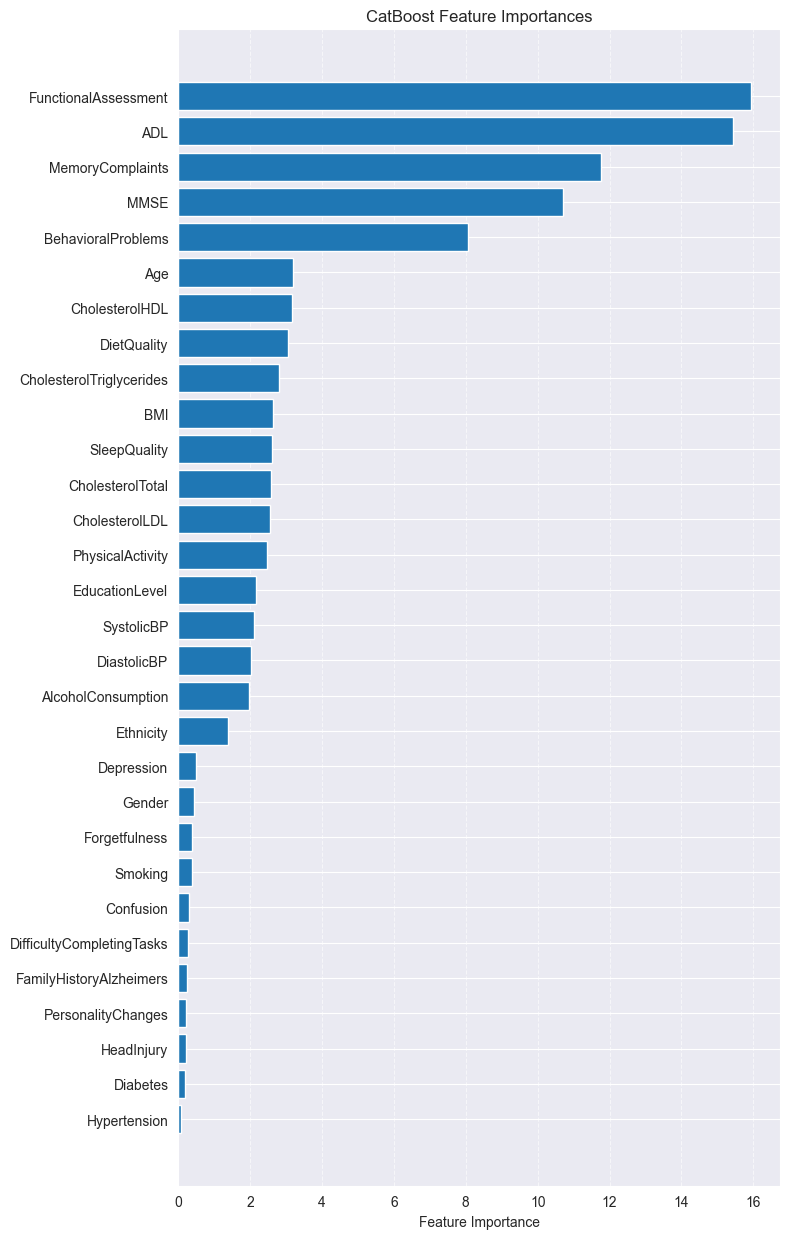

In [27]:
import matplotlib.pyplot as plt

importances = best_cb.get_feature_importance(type='FeatureImportance')
features = X_train.columns.to_list()

# 2) Create DataFrame, sort by importance and optionally keep top N
fi = pd.DataFrame({'feature': features, 'importance': importances})
fi = fi.sort_values('importance', ascending=False)
top_n = min(30, len(fi))  # adjust how many features to show
fi_top = fi.head(top_n).iloc[::-1]  # reverse for horizontal bar plot

# 3) Plot horizontal bar chart
plt.figure(figsize=(8, 0.35 * top_n + 2))
plt.barh(fi_top['feature'], fi_top['importance'], color='C0')
plt.xlabel('Feature Importance')
plt.title('CatBoost Feature Importances')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

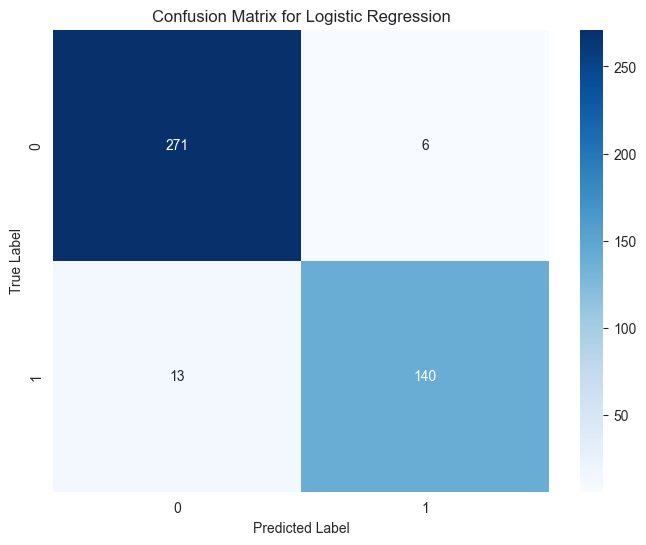

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
# Skrevet av Gemeni
cm = confusion_matrix(y_test, y_pred_cb)

# Get class names from the label encoder
class_names = le.classes_

#0 er ikkje alzheimers, 1 er alzheimers

# Create a heatmap to visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()